In [2]:
from __future__ import annotations

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import mrcfile

from scipy.ndimage import uniform_filter
from scipy.signal import find_peaks
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.cluster import KMeans

In [3]:
class CryoEMSurvey:
    """
    Survey a cryo-EM density map along radial directions from the map center.

    Parameters
    ----------
    cryo_em_map
        3D cryo-EM density map as a NumPy array.
    angspix
        Pixel size in Angstroms per pixel.
    survey_radius_min_angst
        Minimum survey radius in Angstroms.
    survey_radius_angst
        Maximum survey radius in Angstroms.
    grid_theta_min_deg, grid_theta_max_deg, grid_phi_min_deg, grid_phi_max_deg
        Optional angular limits for the survey grid. If not provided, they must
        later be set directly with `set_grid_limits(...)` or computed from
        vectors with `calculate_grid_limits(...)`.
    """

    def __init__(
        self,
        cryo_em_map: np.ndarray,
        angspix: float,
        survey_radius_min_angst: float,
        survey_radius_angst: float,
        grid_theta_min_deg: float | None = None,
        grid_theta_max_deg: float | None = None,
        grid_phi_min_deg: float | None = None,
        grid_phi_max_deg: float | None = None,
    ) -> None:
        self.cryo_em_map = np.asarray(cryo_em_map, dtype=float)
        self.angspix = float(angspix)
        self.survey_radius_min_angst = float(survey_radius_min_angst)
        self.survey_radius_angst = float(survey_radius_angst)

        self.map_dims_pix = np.array(self.cryo_em_map.shape, dtype=int)
        self.center_pos_pix = self.map_dims_pix // 2
        self.center_pos_angst = self.center_pos_pix * self.angspix

        self.grid_theta_min_deg: float | None = grid_theta_min_deg
        self.grid_theta_max_deg: float | None = grid_theta_max_deg
        self.grid_phi_min_deg: float | None = grid_phi_min_deg
        self.grid_phi_max_deg: float | None = grid_phi_max_deg

        self.direction_vectors_angst: np.ndarray | None = None
        self.raw_density_data: dict[int, dict[str, np.ndarray]] | None = None
        self.smoothed_cryo_em_map: np.ndarray | None = None

        provided_grid_limit_count = sum(
            value is not None
            for value in [
                self.grid_theta_min_deg,
                self.grid_theta_max_deg,
                self.grid_phi_min_deg,
                self.grid_phi_max_deg,
            ]
        )

        if provided_grid_limit_count not in (0, 4):
            raise ValueError(
                "You must provide either all four grid limits or none of them: "
                "grid_theta_min_deg, grid_theta_max_deg, "
                "grid_phi_min_deg, grid_phi_max_deg."
            )

        if provided_grid_limit_count == 0:
            warnings.warn(
                "Grid limits have not been provided. Direction vectors cannot be "
                "calculated until grid limits are defined. Use either "
                "set_grid_limits(...) or calculate_grid_limits(...).",
                stacklevel=2,
            )

    def prepare_smoothed_map(
        self,
        window_size: int = 1,
    ) -> None:
        """
        Precompute a uniformly smoothed cryo-EM map.

        Parameters
        ----------
        window_size
            Number of pixels included on each side of the central voxel.
            A value of 1 corresponds to a 3 x 3 x 3 smoothing window.
        """
        if window_size < 0:
            raise ValueError("window_size must be non-negative.")

        filter_size = 2 * window_size + 1

        self.smoothed_cryo_em_map = uniform_filter(
            self.cryo_em_map,
            size=filter_size,
            mode="nearest",
        )

    def set_grid_limits(
        self,
        theta_min_deg: float,
        theta_max_deg: float,
        phi_min_deg: float,
        phi_max_deg: float,
    ) -> None:
        """
        Store angular grid limits on the instance.

        This method overwrites any previously stored grid limits and clears any
        previously stored direction vectors and raw density data.
        """
        self.grid_theta_min_deg = float(theta_min_deg)
        self.grid_theta_max_deg = float(theta_max_deg)
        self.grid_phi_min_deg = float(phi_min_deg)
        self.grid_phi_max_deg = float(phi_max_deg)

        self.direction_vectors_angst = None
        self.raw_density_data = None

        warnings.warn(
            "Grid limits have been updated to: "
            f"theta = {self.grid_theta_min_deg:.2f} --> {self.grid_theta_max_deg:.2f} deg, "
            f"phi = {self.grid_phi_min_deg:.2f} --> {self.grid_phi_max_deg:.2f} deg. "
            "Stored direction vectors and raw density data have been cleared.",
            stacklevel=2,
        )

    def calculate_grid_limits(
        self,
        vectors: np.ndarray,
        vector_units: str,
    ) -> tuple[float, float, float, float]:
        """
        Calculate angular grid limits from input vectors and store them.

        Parameters
        ----------
        vectors
            Array of shape (N, 3) containing vectors referenced to the map
            origin (0, 0, 0).
        vector_units
            Units of the vectors. Must be either 'pixels' or 'angstroms'.

        Returns
        -------
        tuple[float, float, float, float]
            (theta_min_deg, theta_max_deg, phi_min_deg, phi_max_deg)
        """
        vectors = np.asarray(vectors, dtype=float)

        if vectors.ndim != 2 or vectors.shape[1] != 3:
            raise ValueError(
                "vectors must be a 2D NumPy array with shape (N, 3)."
            )

        if vector_units not in ("pixels", "angstroms"):
            raise ValueError(
                "vector_units must be either 'pixels' or 'angstroms'."
            )

        if vector_units == "pixels":
            vectors_angst = vectors * self.angspix
        else:
            vectors_angst = vectors

        theta_values_deg = []
        phi_values_deg = []

        for vector_angst in vectors_angst:
            x_coord_angst, y_coord_angst, z_coord_angst = vector_angst
            vector_length_angst = np.linalg.norm(vector_angst)

            if vector_length_angst == 0:
                raise ValueError(
                    "At least one input vector has zero length, which is not allowed."
                )

            theta_rad = np.arctan2(y_coord_angst, x_coord_angst)
            phi_rad = np.arccos(
                np.clip(z_coord_angst / vector_length_angst, -1.0, 1.0)
            )

            theta_values_deg.append(np.degrees(theta_rad))
            phi_values_deg.append(np.degrees(phi_rad))

        theta_min_deg = float(min(theta_values_deg))
        theta_max_deg = float(max(theta_values_deg))
        phi_min_deg = float(min(phi_values_deg))
        phi_max_deg = float(max(phi_values_deg))

        self.set_grid_limits(
            theta_min_deg=theta_min_deg,
            theta_max_deg=theta_max_deg,
            phi_min_deg=phi_min_deg,
            phi_max_deg=phi_max_deg,
        )

        return (
            theta_min_deg,
            theta_max_deg,
            phi_min_deg,
            phi_max_deg,
        )

    def calculate_direction_vectors_angst(
        self,
        angle_step_deg: float = 0.2,
    ) -> np.ndarray:
        """
        Calculate and store unit direction vectors from the stored grid limits.
        """
        if any(
            value is None
            for value in [
                self.grid_theta_min_deg,
                self.grid_theta_max_deg,
                self.grid_phi_min_deg,
                self.grid_phi_max_deg,
            ]
        ):
            warnings.warn(
                "Direction vectors cannot be calculated because grid limits are "
                "not defined. Use set_grid_limits(...) or "
                "calculate_grid_limits(...) first.",
                stacklevel=2,
            )
            raise ValueError("Grid limits are not defined.")

        theta_range_rad = np.radians(
            np.arange(
                self.grid_theta_min_deg,
                self.grid_theta_max_deg + angle_step_deg,
                angle_step_deg,
            )
        )
        phi_range_rad = np.radians(
            np.arange(
                self.grid_phi_min_deg,
                self.grid_phi_max_deg + angle_step_deg,
                angle_step_deg,
            )
        )

        direction_vectors_angst = []

        for theta_rad in theta_range_rad:
            for phi_rad in phi_range_rad:
                x_coord = np.sin(phi_rad) * np.cos(theta_rad)
                y_coord = np.sin(phi_rad) * np.sin(theta_rad)
                z_coord = np.cos(phi_rad)

                unit_vector_angst = np.array(
                    [x_coord, y_coord, z_coord],
                    dtype=float,
                )
                direction_vectors_angst.append(unit_vector_angst)

        self.direction_vectors_angst = np.array(direction_vectors_angst, dtype=float)

        print(
            f"Generating grid "
            f"(theta = {self.grid_theta_min_deg:.2f} --> {self.grid_theta_max_deg:.2f}, "
            f"phi = {self.grid_phi_min_deg:.2f} --> {self.grid_phi_max_deg:.2f})."
        )
        print(f"Number of direction vectors generated: {len(self.direction_vectors_angst)}")

        return self.direction_vectors_angst

    def survey_map(
        self,
        unit_vector_angst: np.ndarray,
    ) -> np.ndarray:
        """
        Survey the cryo-EM map along a unit direction vector.
        """
        if self.smoothed_cryo_em_map is None:
            self.prepare_smoothed_map(window_size=1)

        survey_radius_min_pix = int(
            np.floor(self.survey_radius_min_angst / self.angspix)
        )
        survey_radius_max_pix = int(
            np.ceil(self.survey_radius_angst / self.angspix)
        )

        radius_values_pix = np.arange(
            survey_radius_min_pix,
            survey_radius_max_pix + 1,
            dtype=int,
        )
        distance_values_angst = radius_values_pix.astype(float) * self.angspix

        sampling_vectors_angst = (
            self.center_pos_angst[None, :]
            + unit_vector_angst[None, :] * distance_values_angst[:, None]
        )

        sampling_vectors_pix = np.rint(
            sampling_vectors_angst / self.angspix
        ).astype(int)

        sampling_vectors_pix = np.clip(
            sampling_vectors_pix,
            [0, 0, 0],
            self.map_dims_pix - 1,
        )

        sampled_intensities = self.smoothed_cryo_em_map[
            sampling_vectors_pix[:, 0],
            sampling_vectors_pix[:, 1],
            sampling_vectors_pix[:, 2],
        ]

        return np.column_stack((distance_values_angst, sampled_intensities))

    def calculate_raw_density_data(self) -> dict[int, dict[str, np.ndarray]]:
        """
        Survey the map for each stored direction vector.
        """
        if self.direction_vectors_angst is None:
            self.calculate_direction_vectors_angst()

        if self.smoothed_cryo_em_map is None:
            self.prepare_smoothed_map(window_size=1)

        raw_density_data = {}

        for direction_index, unit_vector_angst in enumerate(self.direction_vectors_angst):
            survey_data = self.survey_map(unit_vector_angst)
            raw_density_data[direction_index] = {
                "unit_vector_angst": unit_vector_angst,
                "survey_data": survey_data,
            }

        self.raw_density_data = raw_density_data
        print("Raw density data calculated!")

In [4]:
class DiagnosticPlotting:
    """
    Shared diagnostic point-cloud plotting for dataframe-backed models.

    Only numeric columns are allowed for coloring, and they are always
    rendered using a continuous color scale.
    """

    def _get_plot_frame(self) -> pd.DataFrame:
        raise NotImplementedError

    def _prepare_plot_frame(
        self,
        color_by: str,
    ) -> pd.DataFrame:
        plot_frame = self._get_plot_frame()
        if plot_frame.empty:
            raise ValueError("The plot frame is empty, so nothing can be plotted.")

        required_columns = {"x", "y", "z", color_by}
        missing_columns = sorted(required_columns - set(plot_frame.columns))
        if missing_columns:
            raise ValueError(
                "The plot frame is missing required columns: "
                f"{missing_columns}"
            )

        if not pd.api.types.is_numeric_dtype(plot_frame[color_by]):
            raise TypeError(
                f"'{color_by}' must be numeric for diagnostic plotting."
            )

        valid_mask = plot_frame[["x", "y", "z", color_by]].notna().all(axis=1)
        filtered_frame = plot_frame.loc[valid_mask].copy().reset_index(drop=True)
        if filtered_frame.empty:
            raise ValueError(
                "No rows contain finite x, y, z, and color_by values for plotting."
            )

        return filtered_frame

    def static_plot(
        self,
        color_by: str = "intensity",
        marker_size: float = 10,
        alpha: float = 0.7,
    ) -> None:
        plot_frame = self._prepare_plot_frame(color_by=color_by)

        x_vals = plot_frame["x"].to_numpy(dtype=float)
        y_vals = plot_frame["y"].to_numpy(dtype=float)
        z_vals = plot_frame["z"].to_numpy(dtype=float)
        color_values = plot_frame[color_by].to_numpy(dtype=float)

        figure = plt.figure(figsize=(10, 8))
        axis = figure.add_subplot(111, projection="3d")

        scatter = axis.scatter(
            x_vals,
            y_vals,
            z_vals,
            c=color_values,
            cmap="viridis",
            s=marker_size,
            alpha=alpha,
        )

        colorbar = plt.colorbar(scatter, ax=axis, shrink=0.6)
        colorbar.set_label(color_by)

        axis.set_title(f"{self.__class__.__name__} Colored by {color_by}")
        axis.set_xlabel("X (Å)")
        axis.set_ylabel("Y (Å)")
        axis.set_zlabel("Z (Å)")

        plt.tight_layout()
        plt.show()

    def interactive_plot(
        self,
        color_by: str = "intensity",
        marker_size: float = 5,
        opacity: float = 0.8,
    ) -> None:
        plot_frame = self._prepare_plot_frame(color_by=color_by)

        x_vals = plot_frame["x"].to_numpy(dtype=float)
        y_vals = plot_frame["y"].to_numpy(dtype=float)
        z_vals = plot_frame["z"].to_numpy(dtype=float)
        color_values = plot_frame[color_by].to_numpy(dtype=float)

        traces = [
            go.Scatter3d(
                x=x_vals,
                y=y_vals,
                z=z_vals,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_values,
                    colorscale="Viridis",
                    colorbar=dict(title=color_by),
                    opacity=opacity,
                ),
                name=color_by,
            )
        ]

        layout = go.Layout(
            title=f"{self.__class__.__name__} Colored by {color_by}",
            scene=dict(
                xaxis_title="X (Å)",
                yaxis_title="Y (Å)",
                zaxis_title="Z (Å)",
            ),
            height=700,
        )

        figure = go.Figure(data=traces, layout=layout)
        figure.show()

In [5]:
class MaximaModel(DiagnosticPlotting):
    """
    Identify intensity peaks from surveyed density profiles and manage a
    working maxima model.
    """

    def __init__(
        self,
        survey,
        peak_filter: float = 0.009,
    ) -> None:
        if survey.raw_density_data is None:
            raise ValueError(
                "The CryoEMSurvey object does not contain raw_density_data. "
                "Run calculate_raw_density_data() first."
            )

        self.survey = survey
        self.raw_density_data = survey.raw_density_data
        self.peak_filter = peak_filter

        self.raw_peak_data_array = self._build_peak_data_array()
        self.current_maxima_model = self._build_current_maxima_model()

    def _build_peak_data_array(self) -> np.ndarray:
        """
        Detect peaks in each surveyed direction and combine them into one array.
        """
        peak_rows: list[list[float]] = []

        for direction_index in sorted(self.raw_density_data):
            unit_vector_angst = np.asarray(
                self.raw_density_data[direction_index]["unit_vector_angst"],
                dtype=float,
            )
            survey_data = np.asarray(
                self.raw_density_data[direction_index]["survey_data"],
                dtype=float,
            )

            if survey_data.size == 0:
                continue

            distances = survey_data[:, 0]
            intensities = survey_data[:, 1]

            peak_indices, _ = find_peaks(
                intensities,
                height=self.peak_filter,
                distance=4,
                width=2,
            )

            for peak_index in peak_indices:
                distance = float(distances[peak_index])
                intensity = float(intensities[peak_index])

                x, y, z = unit_vector_angst * distance

                peak_rows.append([
                    x,
                    y,
                    z,
                    intensity,
                    distance,
                    direction_index,
                ])

        if not peak_rows:
            return np.empty((0, 6), dtype=float)

        return np.array(peak_rows, dtype=float)

    def _build_current_maxima_model(self) -> pd.DataFrame:
        """
        Build the working maxima model DataFrame from raw_peak_data_array.
        """
        return pd.DataFrame(
            self.raw_peak_data_array,
            columns=[
                "x",
                "y",
                "z",
                "intensity",
                "distance",
                "direction_index",
            ],
        )

    def recover_initial_maxima_model(self) -> None:
        """
        Restore current_maxima_model to the original model built at initialization.
        """
        self.current_maxima_model = self._build_current_maxima_model().reset_index(drop=True)

    def initial_k_clustering(
        self,
        amount_of_clusters: int,
    ) -> None:
        """
        Run the initial K-means clustering on current_maxima_model.
        """
        if self.current_maxima_model.empty:
            raise ValueError(
                "current_maxima_model is empty, so clustering cannot be performed."
            )

        if len(self.current_maxima_model) < amount_of_clusters:
            raise ValueError(
                "The number of detected peaks is smaller than amount_of_clusters."
            )

        intensity_values = self.current_maxima_model["intensity"].to_numpy(dtype=float)
        distance_values = self.current_maxima_model["distance"].to_numpy(dtype=float)

        max_intensity = np.max(intensity_values)
        max_distance = np.max(distance_values)

        if max_intensity == 0:
            raise ValueError(
                "Maximum intensity is zero, so the clustering weight cannot be calculated."
            )

        density_clustering_weight = max_distance / max_intensity * 100
        weighted_intensity_values = intensity_values * density_clustering_weight

        print(density_clustering_weight)

        clustering_input = np.column_stack((
            weighted_intensity_values,
            distance_values,
        ))

        kmeans = KMeans(
            n_clusters=amount_of_clusters,
            random_state=0,
            n_init=10,
        )
        cluster_labels = kmeans.fit_predict(clustering_input)

        self.current_maxima_model["cluster"] = cluster_labels

    def select_cluster(
        self,
        clusters: int | list[int] | tuple[int, ...] | np.ndarray,
    ) -> None:
        """
        Select one or more clusters from current_maxima_model and update
        the working model.
        """
        if self.current_maxima_model.empty:
            raise ValueError(
                "current_maxima_model is empty, so no cluster can be selected."
            )

        if "cluster" not in self.current_maxima_model.columns:
            raise ValueError(
                "The 'cluster' column is not present in current_maxima_model. "
                "Run initial_k_clustering(...) or voxel_connection(...) first."
            )

        if isinstance(clusters, (int, np.integer)):
            selected_clusters = [int(clusters)]
        else:
            selected_clusters = [int(cluster) for cluster in clusters]

        available_clusters = self.current_maxima_model["cluster"].unique().tolist()
        missing_clusters = [
            cluster for cluster in selected_clusters
            if cluster not in available_clusters
        ]

        if missing_clusters:
            raise ValueError(
                f"Clusters {missing_clusters} are not present in current_maxima_model. "
                f"Available clusters are: {sorted(available_clusters)}"
            )

        self.current_maxima_model = (
            self.current_maxima_model[
                self.current_maxima_model["cluster"].isin(selected_clusters)
            ]
            .copy()
            .reset_index(drop=True)
        )

    def voxel_connection(
        self,
        voxel_size: float,
        expected_structure_count: int,
        min_neighbor_voxel_count: int = 2,
        connectivity: str = "26",
    ) -> None:
        """
        Reassign current_maxima_model clusters using voxel-based connected
        components.
        """
        if self.current_maxima_model.empty:
            raise ValueError(
                "current_maxima_model is empty, so voxel connection cannot be performed."
            )

        if voxel_size <= 0:
            raise ValueError("voxel_size must be positive.")

        if expected_structure_count < 1:
            raise ValueError("expected_structure_count must be at least 1.")

        point_matrix = self.current_maxima_model.to_numpy(dtype=float)
        spatial_coordinates = point_matrix[:, 0:3]

        voxel_index_matrix = np.floor(spatial_coordinates / voxel_size).astype(np.int64)

        unique_voxel_indices, point_to_voxel_index = np.unique(
            voxel_index_matrix,
            axis=0,
            return_inverse=True,
        )

        occupied_voxel_count = unique_voxel_indices.shape[0]
        point_labels = np.full(point_matrix.shape[0], -1, dtype=int)

        if occupied_voxel_count < 2:
            self.current_maxima_model["cluster"] = point_labels
            return

        voxel_center_matrix = unique_voxel_indices.astype(np.float64) * voxel_size
        voxel_tree = cKDTree(voxel_center_matrix)

        if connectivity == "6":
            neighbor_radius = 1.01 * voxel_size
        elif connectivity == "18":
            neighbor_radius = 1.01 * np.sqrt(2.0) * voxel_size
        elif connectivity == "26":
            neighbor_radius = 1.01 * np.sqrt(3.0) * voxel_size
        else:
            raise ValueError('connectivity must be one of: "6", "18", "26".')

        neighboring_voxel_pairs = np.array(
            list(voxel_tree.query_pairs(r=neighbor_radius)),
            dtype=np.int64,
        )

        if neighboring_voxel_pairs.size == 0:
            self.current_maxima_model["cluster"] = point_labels
            return

        voxel_neighbor_count = np.zeros(occupied_voxel_count, dtype=np.int64)
        np.add.at(voxel_neighbor_count, neighboring_voxel_pairs[:, 0], 1)
        np.add.at(voxel_neighbor_count, neighboring_voxel_pairs[:, 1], 1)

        supported_voxel_mask = voxel_neighbor_count >= min_neighbor_voxel_count
        supported_voxel_indices = np.where(supported_voxel_mask)[0]

        if supported_voxel_indices.size < 1:
            self.current_maxima_model["cluster"] = point_labels
            return

        old_voxel_index_to_supported_index = -np.ones(occupied_voxel_count, dtype=np.int64)
        old_voxel_index_to_supported_index[supported_voxel_indices] = np.arange(
            supported_voxel_indices.size
        )

        valid_pair_mask = (
            supported_voxel_mask[neighboring_voxel_pairs[:, 0]]
            & supported_voxel_mask[neighboring_voxel_pairs[:, 1]]
        )
        supported_voxel_pairs = neighboring_voxel_pairs[valid_pair_mask]

        if supported_voxel_pairs.size == 0:
            self.current_maxima_model["cluster"] = point_labels
            return

        supported_voxel_pairs = old_voxel_index_to_supported_index[supported_voxel_pairs]

        row_indices = np.concatenate(
            [supported_voxel_pairs[:, 0], supported_voxel_pairs[:, 1]]
        )
        column_indices = np.concatenate(
            [supported_voxel_pairs[:, 1], supported_voxel_pairs[:, 0]]
        )
        edge_values = np.ones(row_indices.shape[0], dtype=np.uint8)

        voxel_graph = coo_matrix(
            (edge_values, (row_indices, column_indices)),
            shape=(supported_voxel_indices.size, supported_voxel_indices.size),
        )

        _, supported_voxel_component_labels = connected_components(
            voxel_graph,
            directed=False,
        )

        component_sizes = np.bincount(supported_voxel_component_labels)
        component_order_descending = np.argsort(component_sizes)[::-1]
        kept_component_indices = component_order_descending[:expected_structure_count]

        voxel_component_labels = np.full(occupied_voxel_count, -1, dtype=int)
        voxel_component_labels[supported_voxel_indices] = supported_voxel_component_labels

        point_component_labels = voxel_component_labels[point_to_voxel_index]

        for new_cluster_label, component_index in enumerate(kept_component_indices):
            point_labels[point_component_labels == component_index] = new_cluster_label

        self.current_maxima_model["cluster"] = point_labels

    def cleanup_per_direction(
        self,
        number_of_neighbors: int = 5,
        epsilon: float = 1e-8,
    ) -> None:
        """
        Clean current_maxima_model by enforcing at most two points per direction.

        Rules
        -----
        - Directions with exactly 2 points are treated as trusted and kept unchanged.
        - Directions with 1 point are kept unchanged, but reported.
        - Directions with more than 2 points are scored against the trusted points,
          and only the best 2 points are kept.
        """
        if self.current_maxima_model.empty:
            raise ValueError(
                "current_maxima_model is empty, so cleanup cannot be performed."
            )

        column_names = list(self.current_maxima_model.columns)

        if "direction_index" not in column_names:
            raise ValueError(
                "current_maxima_model must contain a 'direction_index' column."
            )

        point_matrix = self.current_maxima_model.to_numpy(copy=True)

        x_index = column_names.index("x")
        y_index = column_names.index("y")
        z_index = column_names.index("z")
        direction_index_column = column_names.index("direction_index")

        direction_indices = point_matrix[:, direction_index_column]
        unique_directions, counts = np.unique(direction_indices, return_counts=True)

        trusted_direction_indices = unique_directions[counts == 2]
        singleton_direction_indices = unique_directions[counts == 1]
        crowded_direction_indices = unique_directions[counts > 2]

        print(f"Directions with more than 2 points: {len(crowded_direction_indices)}")
        print(f"Directions with 1 point are kept: {len(singleton_direction_indices)}")

        if len(trusted_direction_indices) == 0:
            raise ValueError(
                "No trusted directions with exactly 2 points were found, "
                "so cleanup cannot be performed."
            )

        kept_row_indices = []

        trusted_direction_mask = np.isin(direction_indices, trusted_direction_indices)
        trusted_row_indices = np.flatnonzero(trusted_direction_mask)
        kept_row_indices.extend(trusted_row_indices.tolist())

        singleton_direction_mask = np.isin(direction_indices, singleton_direction_indices)
        singleton_row_indices = np.flatnonzero(singleton_direction_mask)
        kept_row_indices.extend(singleton_row_indices.tolist())

        trusted_points = point_matrix[trusted_row_indices]
        trusted_coordinates = trusted_points[:, [x_index, y_index, z_index]]

        trusted_tree = cKDTree(trusted_coordinates)
        effective_number_of_neighbors = min(number_of_neighbors, len(trusted_coordinates))

        for direction_index in crowded_direction_indices:
            row_indices = np.flatnonzero(direction_indices == direction_index)
            candidate_points = point_matrix[row_indices]
            candidate_coordinates = candidate_points[:, [x_index, y_index, z_index]]

            distances, _ = trusted_tree.query(
                candidate_coordinates,
                k=effective_number_of_neighbors,
            )

            if effective_number_of_neighbors == 1:
                distances = distances[:, np.newaxis]

            scores = np.sum(1.0 / (distances + epsilon), axis=1)

            best_two_local_positions = np.argpartition(scores, -2)[-2:]
            best_two_row_indices = row_indices[best_two_local_positions]

            kept_row_indices.extend(best_two_row_indices.tolist())

        kept_row_indices = np.array(sorted(kept_row_indices), dtype=int)
        cleaned_matrix = point_matrix[kept_row_indices]

        self.current_maxima_model = pd.DataFrame(
            cleaned_matrix,
            columns=column_names,
        ).reset_index(drop=True)

    def _get_plot_frame(self) -> pd.DataFrame:
        return self.current_maxima_model


In [6]:
class MembraneMorphometry(DiagnosticPlotting):
    """
    Derive leaflet annotations, spacing, and curvature measurements from a
    cleaned maxima model.
    """

    REQUIRED_COLUMNS = {"x", "y", "z", "distance", "direction_index"}

    def __init__(
        self,
        maxima_frame: pd.DataFrame,
    ) -> None:
        if not isinstance(maxima_frame, pd.DataFrame):
            raise TypeError("maxima_frame must be a pandas DataFrame.")

        missing_columns = sorted(self.REQUIRED_COLUMNS - set(maxima_frame.columns))
        if missing_columns:
            raise ValueError(
                "maxima_frame is missing required columns: "
                f"{missing_columns}"
            )

        self.current_membrane_model = maxima_frame.copy().reset_index(drop=True)
        self._ensure_annotation_columns()
        self.assign_leaflets_propagated()

    @classmethod
    def from_maxima_model(
        cls,
        maxima_model,
    ) -> "MembraneMorphometry":
        if not hasattr(maxima_model, "current_maxima_model"):
            raise TypeError(
                "maxima_model must expose a current_maxima_model attribute."
            )

        return cls(maxima_model.current_maxima_model)

    def _ensure_annotation_columns(self) -> None:
        row_count = len(self.current_membrane_model)

        string_columns = [
            "leaflet",
            "leaflet_source",
            "pair_status",
        ]
        for column_name in string_columns:
            if column_name not in self.current_membrane_model.columns:
                self.current_membrane_model[column_name] = pd.Series(
                    pd.array([pd.NA] * row_count, dtype="string")
                )

        if "partner_index" not in self.current_membrane_model.columns:
            self.current_membrane_model["partner_index"] = pd.Series(
                pd.array([pd.NA] * row_count, dtype="Int64")
            )

        float_columns = [
            "leaflet_code",
            "leaflet_vote_score",
            "partner_distance",
            "spacing",
            "k1",
            "k2",
            "gaussian_curvature",
            "mean_curvature",
            "nn_distance",
            "mean_neighbor_distance",
            "outlier_score",
            "is_leaflet_outlier",
        ]
        for column_name in float_columns:
            if column_name not in self.current_membrane_model.columns:
                self.current_membrane_model[column_name] = np.nan

    def to_dataframe(self) -> pd.DataFrame:
        return self.current_membrane_model.copy()

    def _get_plot_frame(self) -> pd.DataFrame:
        return self.current_membrane_model

    def _get_plot_frame_for_leaflet(
        self,
        leaflet: str | None,
    ) -> pd.DataFrame:
        if leaflet is None:
            return self.current_membrane_model

        if leaflet not in {"inner", "outer"}:
            raise ValueError("leaflet must be one of: None, 'inner', 'outer'.")

        filtered_frame = self.current_membrane_model.loc[
            self.current_membrane_model["leaflet"] == leaflet
        ].copy()
        if filtered_frame.empty:
            raise ValueError(f"No rows are available for leaflet '{leaflet}'.")

        return filtered_frame

    def static_plot(
        self,
        color_by: str = "intensity",
        marker_size: float = 10,
        alpha: float = 0.7,
        leaflet: str | None = None,
    ) -> None:
        original_frame = self.current_membrane_model
        try:
            self.current_membrane_model = self._get_plot_frame_for_leaflet(leaflet)
            super().static_plot(
                color_by=color_by,
                marker_size=marker_size,
                alpha=alpha,
            )
        finally:
            self.current_membrane_model = original_frame

    def interactive_plot(
        self,
        color_by: str = "intensity",
        marker_size: float = 5,
        opacity: float = 0.8,
        leaflet: str | None = None,
    ) -> None:
        original_frame = self.current_membrane_model
        try:
            self.current_membrane_model = self._get_plot_frame_for_leaflet(leaflet)
            super().interactive_plot(
                color_by=color_by,
                marker_size=marker_size,
                opacity=opacity,
            )
        finally:
            self.current_membrane_model = original_frame

    def _set_leaflet(
        self,
        row_index: int,
        leaflet_code: int,
        source: str,
    ) -> None:
        if leaflet_code not in (-1, 1):
            raise ValueError("leaflet_code must be either -1 or 1.")

        leaflet_label = "inner" if leaflet_code == -1 else "outer"
        self.current_membrane_model.at[row_index, "leaflet"] = leaflet_label
        self.current_membrane_model.at[row_index, "leaflet_code"] = float(leaflet_code)
        self.current_membrane_model.at[row_index, "leaflet_source"] = source

    def _reset_leaflet_assignment_columns(self) -> None:
        row_count = len(self.current_membrane_model)
        self.current_membrane_model["leaflet"] = pd.Series(
            pd.array([pd.NA] * row_count, dtype="string")
        )
        self.current_membrane_model["leaflet_source"] = pd.Series(
            pd.array([pd.NA] * row_count, dtype="string")
        )
        self.current_membrane_model["leaflet_code"] = np.nan
        self.current_membrane_model["leaflet_vote_score"] = np.nan
        self.current_membrane_model["pair_status"] = pd.Series(
            pd.array([pd.NA] * row_count, dtype="string")
        )

    def _reset_spacing_columns(self) -> None:
        row_count = len(self.current_membrane_model)
        self.current_membrane_model["partner_index"] = pd.Series(
            pd.array([pd.NA] * row_count, dtype="Int64")
        )
        self.current_membrane_model["partner_distance"] = np.nan
        self.current_membrane_model["spacing"] = np.nan

    def _reset_morphometry_columns(self) -> None:
        self.current_membrane_model[[
            "k1",
            "k2",
            "gaussian_curvature",
            "mean_curvature",
        ]] = np.nan

    def _assign_spacing_by_direction(self) -> None:
        """
        Pair rows strictly by direction_index and compute membrane spacing for
        directions that contain exactly two points without changing leaflet labels.
        """
        self._reset_spacing_columns()

        for _, group in self.current_membrane_model.groupby("direction_index", sort=True):
            row_indices = group.index.to_list()

            if len(row_indices) == 2:
                sorted_group = group.sort_values("distance")
                inner_index, outer_index = sorted_group.index.to_list()

                inner_distance = float(self.current_membrane_model.at[inner_index, "distance"])
                outer_distance = float(self.current_membrane_model.at[outer_index, "distance"])
                spacing = outer_distance - inner_distance

                self.current_membrane_model.at[inner_index, "partner_index"] = outer_index
                self.current_membrane_model.at[outer_index, "partner_index"] = inner_index

                self.current_membrane_model.at[inner_index, "partner_distance"] = outer_distance
                self.current_membrane_model.at[outer_index, "partner_distance"] = inner_distance

                self.current_membrane_model.at[inner_index, "spacing"] = spacing
                self.current_membrane_model.at[outer_index, "spacing"] = spacing

    def assign_leaflets_propagated(
        self,
        neighbor_count: int = 12,
        max_neighbor_distance: float | None = None,
    ) -> None:
        """
        Assign leaflets from exact direction pairs, then propagate labels to
        singleton directions using nearby labelled points.
        """
        if neighbor_count < 1:
            raise ValueError("neighbor_count must be at least 1.")

        self._reset_leaflet_assignment_columns()
        self._reset_spacing_columns()
        self._reset_morphometry_columns()
        self.current_membrane_model[[
            "nn_distance",
            "mean_neighbor_distance",
            "outlier_score",
            "is_leaflet_outlier",
        ]] = np.nan

        for _, group in self.current_membrane_model.groupby("direction_index", sort=True):
            row_indices = group.index.to_list()

            if len(row_indices) == 1:
                self.current_membrane_model.at[row_indices[0], "pair_status"] = "unpaired"
                continue

            if len(row_indices) == 2:
                self.current_membrane_model.at[row_indices[0], "pair_status"] = "paired"
                self.current_membrane_model.at[row_indices[1], "pair_status"] = "paired"
                sorted_group = group.sort_values("distance")
                inner_index, outer_index = sorted_group.index.to_list()
                self._set_leaflet(inner_index, -1, "paired")
                self._set_leaflet(outer_index, 1, "paired")
                continue

            for row_index in row_indices:
                self.current_membrane_model.at[row_index, "pair_status"] = "overpopulated"

        labelled_mask = self.current_membrane_model["leaflet_code"].notna()
        if not labelled_mask.any():
            raise ValueError(
                "Leaflet propagation requires at least one direction with exactly two points."
            )

        unlabelled_indices = self.current_membrane_model.index[~labelled_mask].to_list()
        if not unlabelled_indices:
            return

        labelled_coordinates = self.current_membrane_model.loc[
            labelled_mask,
            ["x", "y", "z"],
        ].to_numpy(dtype=float)
        labelled_codes = self.current_membrane_model.loc[
            labelled_mask,
            "leaflet_code",
        ].to_numpy(dtype=float)

        tree = cKDTree(labelled_coordinates)
        query_count = min(neighbor_count, len(labelled_coordinates))

        unlabelled_coordinates = self.current_membrane_model.loc[
            unlabelled_indices,
            ["x", "y", "z"],
        ].to_numpy(dtype=float)
        distances, neighbor_positions = tree.query(unlabelled_coordinates, k=query_count)

        if query_count == 1:
            distances = distances[:, np.newaxis]
            neighbor_positions = neighbor_positions[:, np.newaxis]

        for local_row_position, row_index in enumerate(unlabelled_indices):
            distance_row = np.asarray(distances[local_row_position], dtype=float)
            neighbor_row = np.asarray(neighbor_positions[local_row_position], dtype=int)

            valid_mask = np.isfinite(distance_row)
            if max_neighbor_distance is not None:
                valid_mask &= distance_row <= max_neighbor_distance

            if not valid_mask.any():
                continue

            valid_distances = distance_row[valid_mask]
            valid_codes = labelled_codes[neighbor_row[valid_mask]]

            weights = 1.0 / np.maximum(valid_distances, 1e-12)
            vote_score = float(np.dot(weights, valid_codes) / np.sum(weights))
            propagated_code = 1 if vote_score >= 0.0 else -1

            self._set_leaflet(row_index, propagated_code, "propagated")
            self.current_membrane_model.at[row_index, "leaflet_vote_score"] = vote_score

    def calculate_morphometrics(
        self,
        curvature_neighbor_radius_ratio: float = 20.0,
        min_neighbors: int = 6,
    ) -> None:
        """
        Compute spacing and curvature measurements after leaflet cleanup.
        """
        outlier_mask = self.current_membrane_model["is_leaflet_outlier"] == 1.0
        remaining_outlier_count = int(np.nansum(outlier_mask.to_numpy(dtype=float)))
        if remaining_outlier_count > 0:
            print(
                f"Warning: {remaining_outlier_count} points are still flagged as outliers. "
                "Consider plotting them and removing them before calculating morphometrics."
            )

        self._assign_spacing_by_direction()
        print("Spacing between leaflets calculated.")
        self._reset_morphometry_columns()
        self.compute_principal_curvatures(
            leaflet="inner",
            neighbor_radius_ratio=curvature_neighbor_radius_ratio,
            min_neighbors=min_neighbors,
        )
        print("Inner leaflet curvature calculated.")
        self.compute_principal_curvatures(
            leaflet="outer",
            neighbor_radius_ratio=curvature_neighbor_radius_ratio,
            min_neighbors=min_neighbors,
        )
        print("Outer leaflet curvature calculated.")

    def compute_principal_curvatures(
        self,
        leaflet: str | None = None,
        neighbor_radius_ratio: float = 20.0,
        min_neighbors: int = 6,
    ) -> None:
        """
        Estimate principal curvatures on a leaflet-by-leaflet basis using a
        PCA-aligned local quadratic surface fit.
        """
        if leaflet not in (None, "inner", "outer"):
            raise ValueError("leaflet must be one of: None, 'inner', 'outer'.")

        if neighbor_radius_ratio <= 0.0:
            raise ValueError("neighbor_radius_ratio must be positive.")

        if leaflet is None:
            leaflet_labels = [
                leaflet_label
                for leaflet_label in ("inner", "outer")
                if (self.current_membrane_model["leaflet"] == leaflet_label).any()
            ]
        else:
            leaflet_labels = [leaflet]

        for leaflet_label in leaflet_labels:
            leaflet_mask = self.current_membrane_model["leaflet"] == leaflet_label
            leaflet_frame = self.current_membrane_model.loc[leaflet_mask]

            if leaflet_frame.empty:
                continue

            self.current_membrane_model.loc[
                leaflet_mask,
                ["k1", "k2", "gaussian_curvature", "mean_curvature"],
            ] = np.nan

            coordinates = leaflet_frame[["x", "y", "z"]].to_numpy(dtype=float)
            tree = cKDTree(coordinates)

            if len(coordinates) < 2:
                continue

            nearest_neighbor_distances, _ = tree.query(coordinates, k=2)
            average_nearest_neighbor_distance = float(np.mean(nearest_neighbor_distances[:, 1]))
            if not np.isfinite(average_nearest_neighbor_distance) or average_nearest_neighbor_distance <= 0.0:
                continue
            neighbor_radius = neighbor_radius_ratio * average_nearest_neighbor_distance

            for local_row_position, row_index in enumerate(leaflet_frame.index):
                point = coordinates[local_row_position]
                neighbor_row = np.asarray(
                    tree.query_ball_point(point, r=neighbor_radius),
                    dtype=int,
                )

                if neighbor_row.size < min_neighbors:
                    continue

                neighborhood = coordinates[neighbor_row]
                centered_neighborhood = neighborhood - point

                covariance = centered_neighborhood.T @ centered_neighborhood
                eigenvalues, eigenvectors = np.linalg.eigh(covariance)
                order = np.argsort(eigenvalues)

                normal = eigenvectors[:, order[0]]
                point_norm = np.linalg.norm(point)
                if point_norm > 0.0 and np.dot(normal, point / point_norm) > 0.0:
                    normal = -normal
                normal /= np.linalg.norm(normal)

                tangent_u = eigenvectors[:, order[2]]
                tangent_u /= np.linalg.norm(tangent_u)
                tangent_v = np.cross(normal, tangent_u)
                tangent_v_norm = np.linalg.norm(tangent_v)
                if tangent_v_norm <= 1e-12:
                    continue
                tangent_v /= tangent_v_norm

                local_basis = np.column_stack((tangent_u, tangent_v, normal))
                local_coordinates = centered_neighborhood @ local_basis

                u_coords = local_coordinates[:, 0]
                v_coords = local_coordinates[:, 1]
                w_coords = local_coordinates[:, 2]

                design_matrix = np.column_stack(
                    (
                        0.5 * u_coords**2,
                        u_coords * v_coords,
                        0.5 * v_coords**2,
                        u_coords,
                        v_coords,
                        np.ones_like(u_coords),
                    )
                )

                try:
                    coefficients, _, _, _ = np.linalg.lstsq(
                        design_matrix,
                        w_coords,
                        rcond=None,
                    )
                except np.linalg.LinAlgError:
                    continue

                curvature_uu, curvature_uv, curvature_vv, slope_u, slope_v, _ = coefficients

                first_fundamental_form = np.array(
                    [
                        [1.0 + slope_u**2, slope_u * slope_v],
                        [slope_u * slope_v, 1.0 + slope_v**2],
                    ],
                    dtype=float,
                )
                normal_scale = np.sqrt(1.0 + slope_u**2 + slope_v**2)
                second_fundamental_form = (
                    np.array(
                        [
                            [curvature_uu, curvature_uv],
                            [curvature_uv, curvature_vv],
                        ],
                        dtype=float,
                    )
                    / normal_scale
                )

                try:
                    shape_operator = np.linalg.solve(
                        first_fundamental_form,
                        second_fundamental_form,
                    )
                except np.linalg.LinAlgError:
                    continue

                principal_curvatures = np.linalg.eigvalsh(shape_operator)
                k1 = float(principal_curvatures[0])
                k2 = float(principal_curvatures[1])

                self.current_membrane_model.at[row_index, "k1"] = k1
                self.current_membrane_model.at[row_index, "k2"] = k2
                self.current_membrane_model.at[row_index, "gaussian_curvature"] = k1 * k2
                self.current_membrane_model.at[row_index, "mean_curvature"] = 0.5 * (k1 + k2)

    def diagnose_leaflet_outliers(
        self,
        leaflet: str | None = None,
        neighbor_count: int = 8,
        sd_multiplier: float = 3.0,
    ) -> None:
        """
        Diagnose spatial outliers within each leaflet using same-leaflet
        nearest-neighbor distances and a mean/standard-deviation threshold.
        """
        if leaflet not in (None, "inner", "outer"):
            raise ValueError("leaflet must be one of: None, 'inner', 'outer'.")

        if neighbor_count < 1:
            raise ValueError("neighbor_count must be at least 1.")

        if sd_multiplier < 0.0:
            raise ValueError("sd_multiplier must be non-negative.")

        if leaflet is None:
            leaflet_labels = [
                leaflet_label
                for leaflet_label in ("inner", "outer")
                if (self.current_membrane_model["leaflet"] == leaflet_label).any()
            ]
        else:
            leaflet_labels = [leaflet]

        if not leaflet_labels:
            raise ValueError("No leaflet-labelled points are available for outlier diagnosis.")

        target_mask = self.current_membrane_model["leaflet"].isin(leaflet_labels)
        self.current_membrane_model.loc[
            target_mask,
            ["nn_distance", "mean_neighbor_distance", "outlier_score", "is_leaflet_outlier"],
        ] = np.nan

        for leaflet_label in leaflet_labels:
            leaflet_mask = self.current_membrane_model["leaflet"] == leaflet_label
            leaflet_frame = self.current_membrane_model.loc[leaflet_mask]
            if leaflet_frame.empty:
                continue

            coordinates = leaflet_frame[["x", "y", "z"]].to_numpy(dtype=float)
            point_count = len(coordinates)

            if point_count < 2:
                self.current_membrane_model.loc[leaflet_frame.index, "is_leaflet_outlier"] = 0.0
                continue

            tree = cKDTree(coordinates)
            query_count = min(neighbor_count + 1, point_count)
            distances, _ = tree.query(coordinates, k=query_count)

            neighbor_distances = np.asarray(distances[:, 1:], dtype=float)
            nn_distance = neighbor_distances[:, 0]
            mean_neighbor_distance = np.nanmean(neighbor_distances, axis=1)

            finite_mask = np.isfinite(mean_neighbor_distance)
            if not finite_mask.any():
                self.current_membrane_model.loc[leaflet_frame.index, "is_leaflet_outlier"] = 0.0
                continue

            baseline = mean_neighbor_distance[finite_mask]
            mean_distance = float(np.mean(baseline))
            standard_deviation = float(np.std(baseline))

            outlier_score = np.full(point_count, np.nan, dtype=float)
            if standard_deviation > 0.0:
                outlier_score[finite_mask] = (
                    mean_neighbor_distance[finite_mask] - mean_distance
                ) / standard_deviation
                outlier_threshold = mean_distance + sd_multiplier * standard_deviation
            else:
                outlier_score[finite_mask] = mean_neighbor_distance[finite_mask] - mean_distance
                outlier_threshold = mean_distance

            is_leaflet_outlier = np.zeros(point_count, dtype=float)
            is_leaflet_outlier[finite_mask] = (
                mean_neighbor_distance[finite_mask] > outlier_threshold
            ).astype(float)

            self.current_membrane_model.loc[leaflet_frame.index, "nn_distance"] = nn_distance
            self.current_membrane_model.loc[leaflet_frame.index, "mean_neighbor_distance"] = mean_neighbor_distance
            self.current_membrane_model.loc[leaflet_frame.index, "outlier_score"] = outlier_score
            self.current_membrane_model.loc[leaflet_frame.index, "is_leaflet_outlier"] = is_leaflet_outlier

            outlier_count = int(np.nansum(is_leaflet_outlier))
            print(
                f"Leaflet '{leaflet_label}': {outlier_count} outliers out of {point_count} points. "
                "Plot 'is_leaflet_outlier' or 'outlier_score' to verify them."
            )

    def eliminate_outliers(self) -> None:
        """
        Remove points currently flagged as leaflet outliers.
        """
        if "is_leaflet_outlier" not in self.current_membrane_model.columns:
            raise ValueError("Run diagnose_leaflet_outliers() before eliminate_outliers().")

        if self.current_membrane_model["is_leaflet_outlier"].isna().all():
            raise ValueError("Run diagnose_leaflet_outliers() before eliminate_outliers().")

        outlier_mask = self.current_membrane_model["is_leaflet_outlier"] == 1.0
        removed_count = int(np.nansum(outlier_mask.to_numpy(dtype=float)))
        if removed_count == 0:
            print("No outliers are currently flagged, so no rows were removed.")
            return

        self.current_membrane_model = (
            self.current_membrane_model.loc[~outlier_mask]
            .copy()
            .reset_index(drop=True)
        )
        print(f"Removed {removed_count} outliers from the membrane model.")



In [7]:
map_path = "data/refine_job120_postcleaned_ctf.mrc"

with mrcfile.open(map_path, permissive=True) as mrc:
    cryo_em_map = np.array(mrc.data, dtype=float)

In [8]:
survey = CryoEMSurvey(
    cryo_em_map=cryo_em_map,
    angspix=3.026,
    survey_radius_min_angst=600,
    survey_radius_angst=900,
    grid_theta_min_deg=5,
    grid_theta_max_deg=170,
    grid_phi_min_deg=103,
    grid_phi_max_deg=175,
)


survey.calculate_direction_vectors_angst(angle_step_deg=0.2)
survey.calculate_raw_density_data()

Generating grid (theta = 5.00 --> 170.00, phi = 103.00 --> 175.00).
Number of direction vectors generated: 298186
Raw density data calculated!


In [9]:
maxima_model = MaximaModel(survey=survey,peak_filter=0.01)

2926258.9656426637


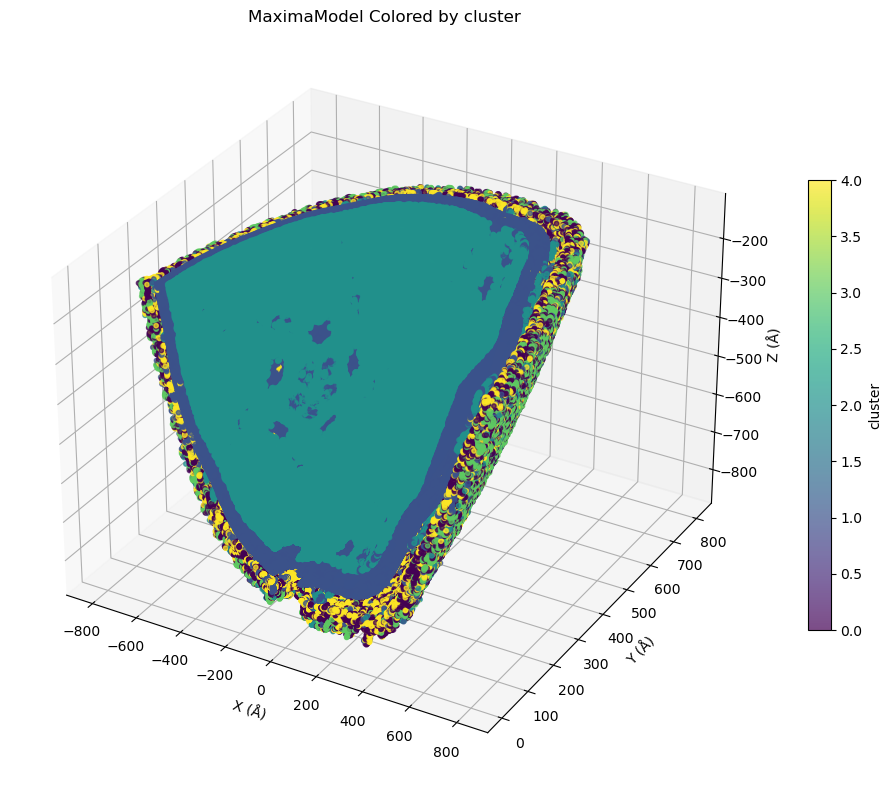

In [10]:
maxima_model.initial_k_clustering(amount_of_clusters=5)
maxima_model.static_plot(color_by="cluster")

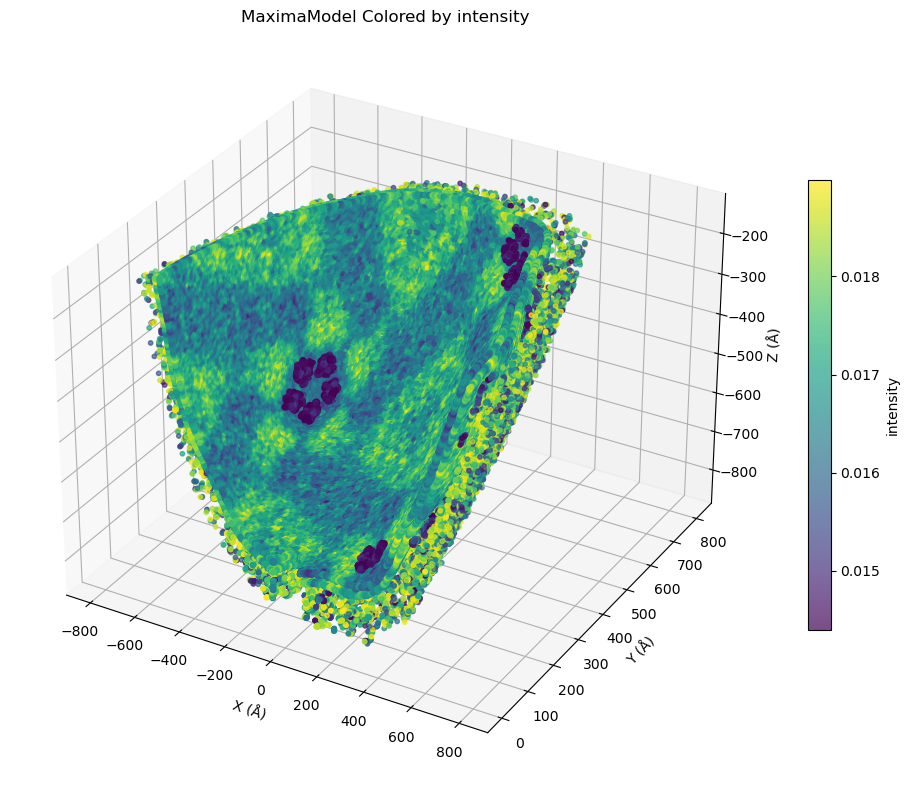

In [11]:
maxima_model.select_cluster(1)
maxima_model.static_plot(color_by="intensity")

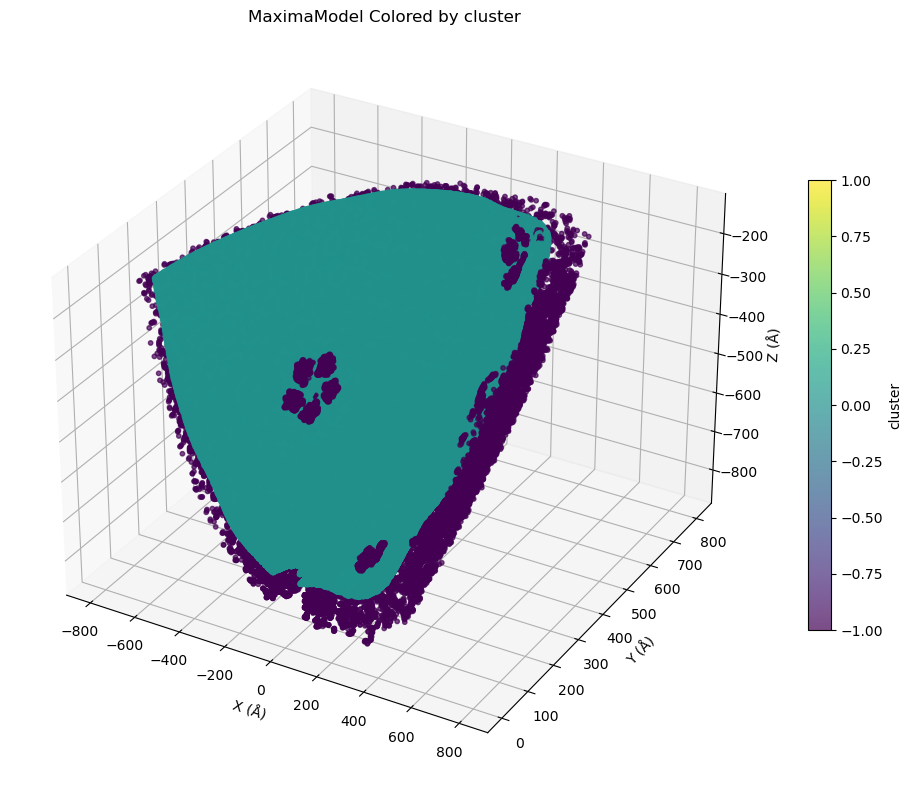

In [12]:
maxima_model.voxel_connection(voxel_size=5.5,
                              connectivity="6",
                              expected_structure_count=2,
                              min_neighbor_voxel_count=1
                             )
maxima_model.static_plot(color_by="cluster")

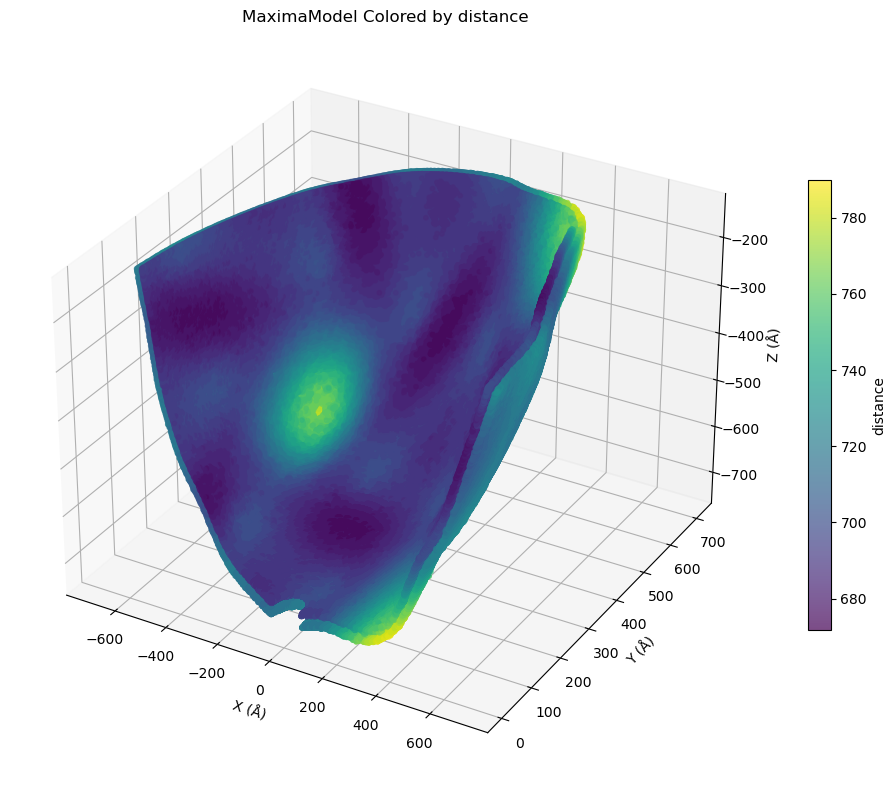

In [13]:
maxima_model.select_cluster(0)
maxima_model.static_plot(color_by="distance")

In [14]:
maxima_model.cleanup_per_direction()

Directions with more than 2 points: 9
Directions with 1 point are kept: 8351


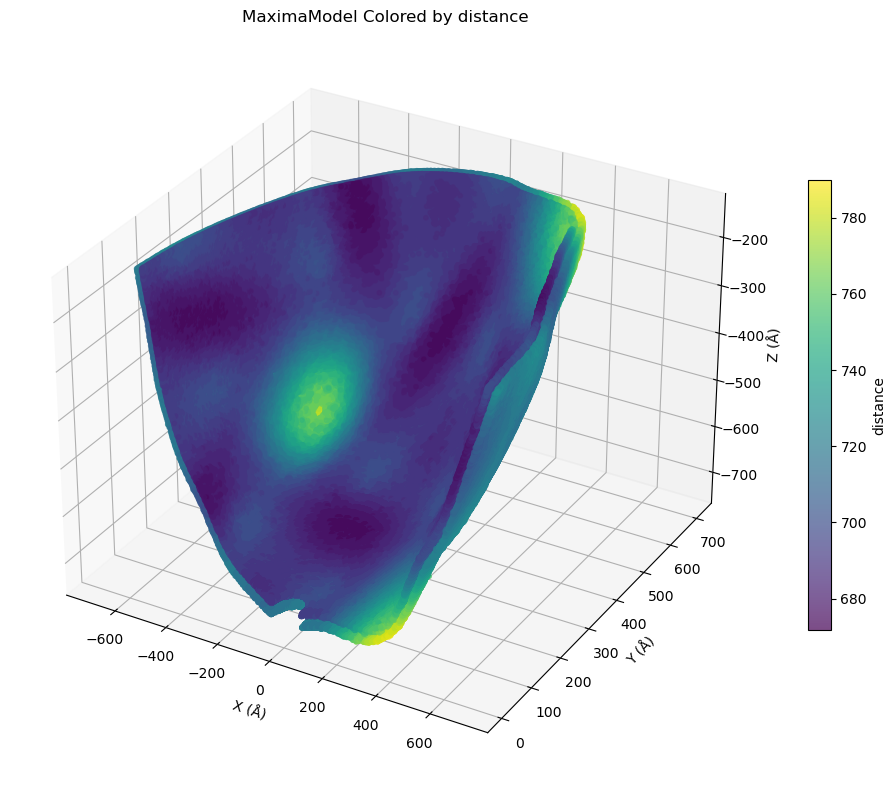

In [15]:
maxima_model.static_plot(color_by="distance")

In [16]:
membrane = MembraneMorphometry.from_maxima_model(maxima_model)

In [17]:
membrane.diagnose_leaflet_outliers(sd_multiplier=5)

Leaflet 'inner': 57 outliers out of 293611 points. Plot 'is_leaflet_outlier' or 'outlier_score' to verify them.
Leaflet 'outer': 9 outliers out of 294174 points. Plot 'is_leaflet_outlier' or 'outlier_score' to verify them.


In [18]:
membrane.eliminate_outliers()

Removed 66 outliers from the membrane model.


In [34]:
membrane.calculate_morphometrics(curvature_neighbor_radius_ratio = 30)

Spacing between leaflets calculated.
Inner leaflet curvature calculated.
Outer leaflet curvature calculated.


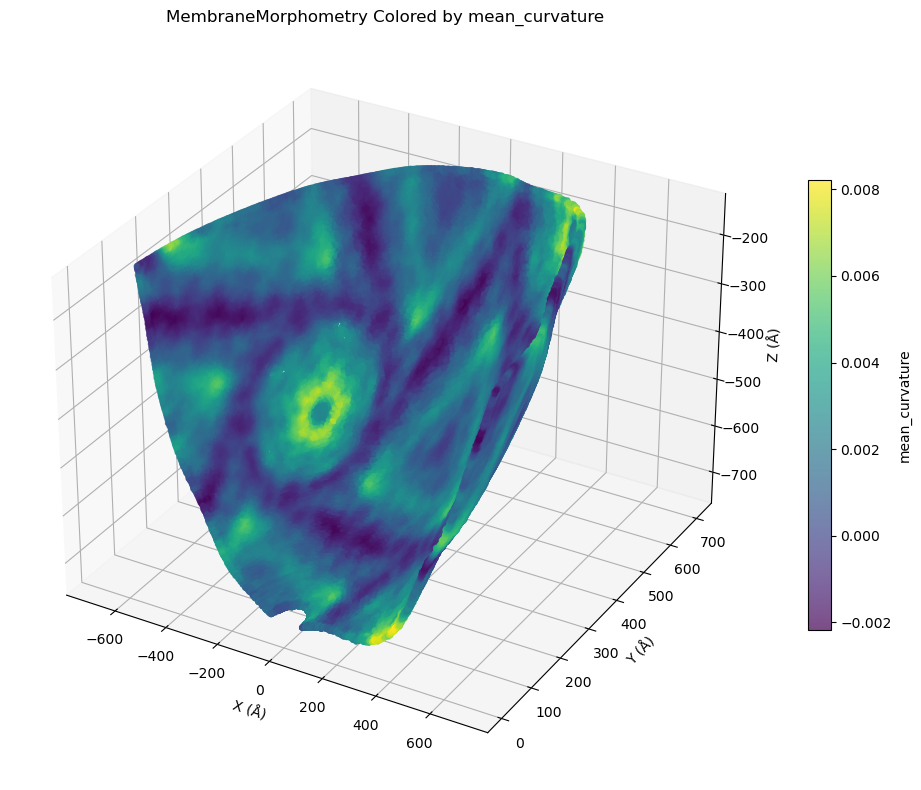

In [35]:
membrane.static_plot(color_by="mean_curvature", leaflet="outer")


In [32]:
np.array(membrane.current_membrane_model)[:,0:3]


array([[678.4987664440902, 59.360950280181484, -157.24213669268772],
       [707.8710074156958, 61.93068838754865, -164.04915559713308],
       [677.9478439549856, 59.312750807903356, -159.61862831256903],
       ...,
       [-64.01077312626228, 11.286826358168225, -714.2104470802276],
       [-59.47738600999369, 10.48746789557394, -690.3171008214684],
       [-61.55519862169652, 10.853842319873467, -714.4329820728734]],
      dtype=object)

In [33]:
def average_nearest_neighbor_distance(points: np.ndarray) -> float:
      """
      Return the average distance from each point to its nearest other point.

      Parameters
      ----------
      points : np.ndarray
          Array of shape (N, 3) with x, y, z coordinates.
      """
      points = np.asarray(points, dtype=float)
      if points.ndim != 2 or points.shape[1] != 3:
          raise ValueError("points must have shape (N, 3).")
      if len(points) < 2:
          raise ValueError("At least two points are required.")

      tree = cKDTree(points)
      distances, _ = tree.query(points, k=2)
      return float(np.mean(distances[:, 1]))



avg_dist = average_nearest_neighbor_distance(np.array(membrane.current_membrane_model)[:,0:3])
print(avg_dist)

1.6181180180590506
